[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# A Dataset for Sentiment Analysis

With the proliferation of online social media and review platforms, a plethora of opinionated data has been logged, bearing great potential for supporting decision making processes.  *Sentiment analysis* studies people's sentiments in their produced text, such as product reviews, blog comments, and forum discussions.  It enjoys wide applications to fields as diverse as politics (e.g., analysis of public sentiments towards policies), finance (e.g., analysis of sentiments of the market), and marketing (e.g., product research and brand management).

Since sentiments can be categorized as discrete polarities or scales (e.g., positive and negative), we can consider sentiment analysis as a *text classification* task, which transforms a varying-length text sequence into a fixed-length category — exactly the kind of problem our recurrent networks are built for.

In this notebook we prepare the data: we will use Stanford's [large movie review dataset](https://ai.stanford.edu/~amaas/data/sentiment/), which consists of a training set and a test set, each containing 25,000 movie reviews downloaded from IMDb.  In both splits, there are an equal number of "positive" and "negative" labels, indicating different sentiment polarities.  Along the way we build the standard text-processing pipeline — tokenization, a vocabulary, and padding — that turns raw text into the integer tensors a neural network consumes.

In [1]:
import collections
import os
import re
import tarfile
import urllib.request

import torch
from matplotlib import pyplot as plt

## Reading the dataset

First, download and extract the IMDb review dataset into the directory `../data/aclImdb` (the archive is about 84 MB, so this takes a moment the first time).

In [2]:
def download_imdb(data_dir='../data'):
    """Download and extract the IMDb review dataset."""
    # a fast mirror of https://ai.stanford.edu/~amaas/data/sentiment/
    url = 'https://d2l-data.s3-accelerate.amazonaws.com/aclImdb_v1.tar.gz'
    os.makedirs(data_dir, exist_ok=True)
    archive = os.path.join(data_dir, 'aclImdb_v1.tar.gz')
    if not os.path.exists(archive):
        print('downloading', url, '...')
        urllib.request.urlretrieve(url, archive)
    extracted = os.path.join(data_dir, 'aclImdb')
    if not os.path.exists(extracted):
        print('extracting ...')
        with tarfile.open(archive) as tar:
            tar.extractall(data_dir)
    return extracted

data_dir = download_imdb()

Next, read the training and test datasets.  Each example is a review and its label: 1 for "positive" and 0 for "negative".

In [3]:
def read_imdb(data_dir, is_train):
    """Read the IMDb review dataset text sequences and labels."""
    data, labels = [], []
    for label in ('pos', 'neg'):
        folder_name = os.path.join(data_dir, 'train' if is_train else 'test',
                                   label)
        for file in os.listdir(folder_name):
            with open(os.path.join(folder_name, file), 'rb') as f:
                review = f.read().decode('utf-8').replace('\n', '')
                data.append(review)
                labels.append(1 if label == 'pos' else 0)
    return data, labels

train_data = read_imdb(data_dir, is_train=True)
print('number of training examples:', len(train_data[0]))
for x, y in zip(train_data[0][:3], train_data[1][:3]):
    print('\033[1m'+'review:'+'\033[0m', x[:100])
    print('\033[1m'+'label:'+'\033[0m', y)

number of training examples: 25000
review: For a movie that gets no respect there sure are a lot of memorable quotes listed for this gem. Imagi
label: 1
review: Bizarre horror movie filled with famous faces but stolen by Cristina Raines (later of TV's "Flamingo
label: 1
review: A solid, if unremarkable film. Matthau, as Einstein, was wonderful. My favorite part, and the only t
label: 1


## Tokenization

The first step of the pipeline is to split each review into **tokens**.  We use a very simple word-level tokenizer: lowercase the text, remove the HTML line breaks that appear in the raw reviews, and extract runs of word characters.  (Production systems use subword tokenizers; word-level tokens are perfectly adequate here and easier to inspect.)

In [4]:
def tokenize(text):
    """Split a review into a list of lowercased word tokens."""
    text = text.replace('<br />', ' ').lower()
    return re.findall(r"[a-z0-9']+", text)

tokenize("This movie is GREAT!<br />I'd watch it again.")

['this', 'movie', 'is', 'great', "i'd", 'watch', 'it', 'again']

In [5]:
train_tokens = [tokenize(review) for review in train_data[0]]

## The vocabulary

Neural networks consume numbers, not strings, so each token is mapped to an integer index — its **token ID**.  The `Vocab` class below builds this mapping from a corpus.  Two details matter in practice:

* Tokens that appear fewer than `min_freq` times are dropped: rare tokens bloat the vocabulary, and the network cannot learn anything useful from a handful of occurrences anyway.  Any token that is not in the vocabulary (rare, or unseen at training time) is mapped to the special token `<unk>` ("unknown").
* We reserve a `<pad>` token, which we will use below to make all sequences the same length.

In [6]:
class Vocab:
    """A mapping between word tokens and integer indices."""
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        # count and sort by frequency, most frequent first
        counter = collections.Counter(tok for line in tokens for tok in line)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1],
                                  reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens + [
            tok for tok, freq in self.token_freqs if freq >= min_freq]
        self.token_to_idx = {tok: idx
                             for idx, tok in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        """Token(s) -> index/indices; unknown tokens map to <unk> (index 0)."""
        if isinstance(tokens, (list, tuple)):
            return [self[tok] for tok in tokens]
        return self.token_to_idx.get(tokens, self.unk)

    def to_tokens(self, indices):
        """Index/indices -> token(s)."""
        if hasattr(indices, '__len__'):
            return [self.idx_to_token[int(i)] for i in indices]
        return self.idx_to_token[int(indices)]

    @property
    def unk(self):
        return 0

vocab = Vocab(train_tokens, min_freq=5, reserved_tokens=['<pad>'])
print('vocabulary size:', len(vocab))
print('most frequent tokens:', vocab.idx_to_token[2:12])

vocabulary size: 30563
most frequent tokens: ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this']


In [7]:
# round trip: tokens -> indices -> tokens
ids = vocab[train_tokens[0][:8]]
print(train_tokens[0][:8])
print(ids)
print(vocab.to_tokens(ids))

['for', 'a', 'movie', 'that', 'gets', 'no', 'respect', 'there']
[15, 4, 17, 12, 211, 54, 1157, 47]
['for', 'a', 'movie', 'that', 'gets', 'no', 'respect', 'there']


## Truncation and padding

Let's plot a histogram of the number of tokens per review:

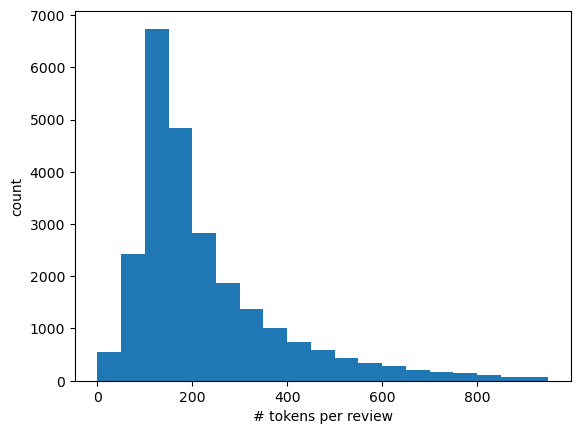

In [8]:
plt.hist([len(line) for line in train_tokens], bins=range(0, 1000, 50))
plt.xlabel('# tokens per review')
plt.ylabel('count');

As we would expect, the reviews have varying lengths.  Recurrent networks can in principle process any length, but to train efficiently we want to stack a minibatch of reviews into a single rectangular tensor.  We therefore fix a length of 500 tokens: longer reviews are *truncated*, and shorter ones are *padded* with the `<pad>` token.

In [9]:
def truncate_pad(line, num_steps, padding_token):
    """Truncate or pad a list of token IDs to exactly num_steps entries."""
    if len(line) > num_steps:
        return line[:num_steps]          # truncate
    return line + [padding_token] * (num_steps - len(line))  # pad

num_steps = 500  # sequence length
train_features = torch.tensor([
    truncate_pad(vocab[line], num_steps, vocab['<pad>'])
    for line in train_tokens])
print(train_features.shape)

torch.Size([25000, 500])


## Creating data iterators

Now we can create data iterators.  At each iteration, a minibatch of examples is returned.

In [10]:
train_iter = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_features,
                                   torch.tensor(train_data[1])),
    batch_size=64, shuffle=True)

for X, y in train_iter:
    print('X:', X.shape, ', y:', y.shape)
    break
print('# batches:', len(train_iter))

X: torch.Size([64, 500]) , y: torch.Size([64])
# batches: 391


## Putting it all together

Last, we wrap up the above steps into the `load_data_imdb` function.  It returns training and test data iterators and the vocabulary of the IMDb review dataset.  We will reuse this pipeline (and the helper functions above) in the next notebook to train a sentiment classifier.

In [11]:
def load_data_imdb(batch_size, num_steps=500):
    """Return data iterators and the vocabulary of the IMDb review dataset."""
    data_dir = download_imdb()
    train_data = read_imdb(data_dir, True)
    test_data = read_imdb(data_dir, False)
    train_tokens = [tokenize(review) for review in train_data[0]]
    test_tokens = [tokenize(review) for review in test_data[0]]
    vocab = Vocab(train_tokens, min_freq=5, reserved_tokens=['<pad>'])
    train_features = torch.tensor([
        truncate_pad(vocab[line], num_steps, vocab['<pad>'])
        for line in train_tokens])
    test_features = torch.tensor([
        truncate_pad(vocab[line], num_steps, vocab['<pad>'])
        for line in test_tokens])
    train_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_features,
                                       torch.tensor(train_data[1])),
        batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(test_features,
                                       torch.tensor(test_data[1])),
        batch_size, shuffle=False)
    return train_iter, test_iter, vocab

train_iter, test_iter, vocab = load_data_imdb(64)
len(vocab)

30563

## Summary

* Sentiment analysis is a text classification problem: a varying-length text sequence is mapped to a fixed set of categories.
* The standard preprocessing pipeline is: tokenize the text, build a vocabulary that maps tokens to integer IDs (dropping rare tokens, mapping unknown ones to `<unk>`), and truncate/pad every sequence to a common length so minibatches form rectangular tensors.
* Note that the vocabulary is built from the *training* split only — the test set must not influence any part of the model, including the token mapping.

## Exercises

1. Our tokenizer discards punctuation.  An exclamation mark might carry sentiment!  Modify `tokenize` to keep `!` and `?` as tokens, rebuild the vocabulary, and check how the vocabulary size changes.
2. How does `min_freq` affect the vocabulary size and the fraction of tokens in the corpus that map to `<unk>`?  Plot both as a function of `min_freq`.
3. We truncate reviews to 500 tokens, which covers most reviews (see the histogram).  What fraction of reviews is truncated?  What are the trade-offs in choosing a shorter length, say 100?